
<h1 id="1.3-ADC/TDC-%E4%BF%A1%E5%8F%B7%E5%A4%84%E7%90%86%EF%BC%9A%E4%BB%8E%E7%89%A9%E7%90%86%E9%87%8F%E5%88%B0%E6%95%B0%E5%AD%97%E5%8C%96">1.3 ADC/TDC 信号处理：从物理量到数字化</h1><h3 id="1.-%E7%9B%AE%E7%9A%84">1. 目的</h3><ol>
<li>掌握模拟电信号（时间、幅度）如何进行数字化（保存为整数道值）。</li>
<li>理解基线偏移（Pedestal）、超界（Overflow）。</li>
<li>有效事件的选择（cut）</li>
</ol>
<hr/>
<h2 id="2.-Digitization-(%E6%95%B0%E5%AD%97%E5%8C%96)">2. Digitization (数字化)</h2><p>在模拟代码中，事件的变量（如 $q_L/q_R$, $t_L/t_R$）通常是用 double 保存的浮点数。但在真实实验中，探测器输出的连续模拟信号经过电子学模块（ADC / TDC / QDC）后，会被量化为<strong>离散的整数（Channel / 道值）</strong>，这个过程就叫数字化。</p>
<h3 id="A.-ADC-/-QDC-(%E6%A8%A1%E6%8B%9F/%E7%94%B5%E8%8D%B7-%E6%95%B0%E5%AD%97%E8%BD%AC%E6%8D%A2%E5%99%A8)">A. ADC / QDC (模拟/电荷-数字转换器)</h3><p>ADC / QDC 用于记录输入信号的大小（ADC 测电压幅度，QDC 测电荷积分）。</p>
<p>假设一个 <strong>12-bit 的 ADC，硬件输入量程为 0-4V</strong>。
它的转换公式可以直白地写为：</p>
<p>$$
\mathrm{Raw\_ADC} = \mathrm{Int}(\text{信号幅度} \times \mathrm{Gain} + \mathrm{Pedestal} + \text{噪声涨落})
$$</p>
<h4 id="%E5%85%B7%E4%BD%93%E5%8F%82%E6%95%B0%E8%AF%B4%E6%98%8E%EF%BC%9A">具体参数说明：</h4><ul>
<li><strong>信号幅度 (Input Signal)</strong>: 实际进入 ADC 的模拟电压（例如 2.5V）。</li>
<li><strong>Gain (增益/转换系数)</strong>: 把电压映射到道值的比例。<ul>
<p>理想 0–4 V 量程对应 4096 个码，Gain=4096/4000=1.024 ch/mV。未加 pedestal 时，2.5 V 对应 2560 ch。</p>
</ul>
</li>
<li><strong>Pedestal (基线/直流偏置)</strong>:<ul>
<li>因为真实的零信号总带有电子学噪声，噪声有正有负。如果基线设在 0 ch，负向噪声就会被 ADC 丢弃（无法记录负数）。</li>
<p>可加入直流偏置把 pedestal 均值移到正道值，如 140 ch，以减少负向噪声被量程截断；这不保证任意噪声样本都在量程内。</p>
<p>无物理信号时，读数仍有分布。其均值用来扣除 pedestal offset，宽度反映噪声；是否近似 Gaussian 应从数据检查。扣除均值不等于消除了逐事例噪声。</p>
</ul>
</li>
</ul>
<p><img alt="1" src="fig/adc_ped.png"/></p>
<ul>
<li><strong>Range (量程)</strong>:<ul>
<li>12-bit: <code>0 ~ 4095</code> ch</li>
<li>14-bit: <code>0 ~ 16383</code> ch</li>
</ul>
</li>
<li>本模拟把超量程值记为最大码。真实模块可能另有 overflow 状态或编码，应按模块说明处理。</li>
</ul>
<hr/>
<h3 id="B.-TDC-(%E6%97%B6%E9%97%B4-%E6%95%B0%E5%AD%97%E8%BD%AC%E6%8D%A2%E5%99%A8)">B. TDC (时间-数字转换器)</h3><p>TDC 用于记录 <code>Start</code> 和 <code>Stop</code> 两个信号之间的时间差。</p>
<p>假设这个 <strong>TDC 的时间测量量程是 0-100ns，数字编码为 12-bit (0-4095 ch)</strong>。
它的转换公式为：</p>
<p>$$
\mathrm{Raw\_TDC} = \mathrm{Int}\left( (T_{\mathrm{stop}} - T_{\mathrm{start}} + \mathrm{Delay}) \times \mathrm{转换系数} \right)
$$</p>
<h4 id="%E5%85%B7%E4%BD%93%E5%8F%82%E6%95%B0%E8%AF%B4%E6%98%8E%EF%BC%9A">具体参数说明：</h4><ul>
<li><strong>转换系数</strong>: 把时间差换算成道值的系数。<ul>
<li>在这个例子中，100ns 对应 4096 个道址，转换系数就是 $4096 / 100\mathrm{ns} \approx 40.96 \text{ ch/ns}$。</li>
</ul>
</li>
<li><strong>Delay</strong>:<ul>
<li>TDC 只能测正的时间差（0-100ns）。但在实际连线中，因为电缆长度或触发逻辑，<code>Stop</code> 信号有可能比 <code>Start</code> 信号先到（时间差变成负的，比如 -10ns），TDC 就无法记录。</li>
<li>在硬件或逻辑上给信号强行加上一段固定的 Delay（比如 +30ns），把原本 -10ns 的时间差整体平移到 +20ns，让它稳稳地落在 0-100ns 的合法量程内。</li>
</ul>
</li>
<li><strong>Range (量程)</strong>:<ul>
<li>12-bit: <code>0 ~ 4095</code> ch</li>
<li>14-bit: <code>0 ~ 16383</code> ch</li>
</ul>
</li>
<li>本模拟把超量程值记为最大码。真实模块可能另有 overflow 状态或编码，应按模块说明处理。</li>
</ul>
<h3 id="3.-%E7%89%A9%E7%90%86%E8%BF%87%E7%A8%8B">3. 物理过程</h3><ul>
<li>束流轰击靶以产生带电粒子、n、$\gamma$等粒子,重带电粒子碎片被靶后 Dipole magnet偏走，而部分轻带电粒子(LP: light particles，主要为质子)没有被完全偏走，仍然进入中子探测器。</li>
</ul>
<p>真实数据获取 (DAQ) 中，触发逻辑决定了我们记录什么事件：</p>
<ul>
<li><strong>物理触发 (Trig_Phys)</strong>：中子，Gamma或LP 击中探测器。(<code>pid=0, 1，2</code>)</li>
<li>束流/时钟触发用于监测基线。本模拟把 pid=3 设为无物理信号事件；真实的时钟触发仍可能与粒子信号偶然重叠。</li>
</ul>
<hr/>
<h3 id="4.-%E4%BB%A3%E7%A0%81%EF%BC%9A%E5%9F%BA%E4%BA%8E-1.1-%E4%BB%A3%E7%A0%81%E8%BF%9B%E8%A1%8C%E4%BF%AE%E6%94%B9">4. 代码：基于 1.1 代码进行修改</h3><h4 id="%E5%AE%9A%E4%B9%89%E6%95%B0%E5%AD%97%E5%8C%96%E5%8F%82%E6%95%B0%E4%B8%8E%E5%88%86%E6%94%AF">定义数字化参数与分支</h4><div class="highlight"><pre><code class="language-cpp">// --- 新增变量 ---
Int_t iAL, iAR;  // QDC道值 (0-4095)
Int_t itL, itR;  // TDC道值 (0-4095)
// 复用已有 pid：0:G, 1:N, 2:LP, 3:Pedestal

// --- 数字化与电子学参数 ---
const Double_t ADC_Gain = 5.0;    // 增益
const Double_t TDC_Gain = 25.0;   // 转换系数 (如40ps/ch)
const Double_t Ped_L = 140.0, Ped_R = 130.0; // 基线
const Double_t Noise = 8.5;       // 电子学噪声
const Double_t Trig_Dly = 50.0;   // 延迟
const Int_t    Max_ADC = 4095;    // 12-bit
const Int_t    Threshold = 180;   // 触发阈值(道值)

// --- Branch 映射 (省略原有部分) ---
// pid 分支已在原模拟中建立，不再重复声明。
opt-&gt;Branch("iAL", &amp;iAL, "iAL/I"); // ... 其余同理</code></pre></div>
<h4 id="%E4%BA%8B%E4%BB%B6%E7%94%9F%E6%88%90-($E_n-%5Cto-E_p-%5Cto-E_%7Bee%7D$)">事件生成 ($E_n \to E_p \to E_{ee}$)</h4><div class="highlight"><pre><code class="language-cpp">// 1. 抽样生成 pid
Double_t rnd = gr-&gt;Uniform();
if (rnd &lt; 0.10)      pid = 3; // 空触发/时钟触发
else if (rnd &lt; 0.20) pid = 2; // LP (质子)
else                 pid = (gr-&gt;Uniform() &lt; 0.3) ? 0 : 1;

// 2. 物理过程修改
...
if (pid == 2) {
    Eee = gr-&gt;Gaus(50.0, 5.0);           // 此处直接指定 LP 的示意光输出分布（MeVee）
}
if (pid == 3) {
    Eee = 0.0;                           // Pedestal 无能量
}</code></pre></div>
<h4 id="%E6%95%B0%E5%AD%97%E5%8C%96-(Digitization)-%E4%B8%8E-%E8%A7%A6%E5%8F%91%E9%80%BB%E8%BE%91-(Trigger)">数字化 (Digitization) 与 触发逻辑 (Trigger)</h4><div class="highlight"><pre><code class="language-cpp">...

// 1. ADC: 幅度 * 增益 + 基线 + 噪声
iAL = (Int_t)(AL* ADC_Gain + Ped_L + gr-&gt;Gaus(0, Noise));
iAR = (Int_t)(AR * ADC_Gain + Ped_R + gr-&gt;Gaus(0, Noise));

// 2. TDC: (时间 + 延迟) * 转换系数
if (pid == 3) {
    itL = Max_ADC; itR = Max_ADC; // 无物理信号，TDC默认溢出
} else {
    itL = (Int_t)((tL + Trig_Dly) * TDC_Gain );
    itR = (Int_t)((tR + Trig_Dly) * TDC_Gain );
}

// 3. 超界截断处理
if (iAL &gt; Max_ADC) iAL = Max_ADC; if (iAL &lt; 0) iAL = 0;
// ... iAR, itL, itR 同理 ...

// 4. DAQ 触发逻辑 (物理符合触发 OR 时钟触发)
bool Trig_Phys = (iAL &gt; Threshold) &amp;&amp; (iAR &gt; Threshold);
bool Trig_Clock = (pid == 3);

if (Trig_Phys || Trig_Clock) {
    opt-&gt;Fill(); // 只有满足触发条件才存入 Tree
}</code></pre></div>
<h3>道值、量程与状态</h3><p>12-bit ADC 有 4096 个码。理想 0–4 V 量程的步距为 \(4/4096\) V，约 0.977 mV；码间距不是完整的仪器精度。Pedestal 是无物理信号时的基线分布，均值为 pedestal offset、宽度反映噪声，增加 offset 不保证所有噪声样本都为正。</p><p>本例约定超量程信号饱和到最大码；真实 ADC/TDC 对 overflow、无命中和无效时间的编码应查对应模块。TDC 的符号和有效区间还取决于 common-start/common-stop 等读出方式。</p>

<h2>2. 数字化数据的处理</h2><h3>Pedestal 与有效区间</h3><p>先画原始 channel 分布，识别 pedestal、物理信号和无效码。阈值由噪声水平与信号需求选择。对理想 Gaussian 噪声，单侧超过均值 3σ 的概率约 0.135%；这是纯噪声的越阈概率，不是“该事例为真实信号的概率”。对数、开方及倒数运算前，检查其输入是否有效。</p><h3>量化与 Dithering</h3><p>ADC/TDC 原始整数道值可以直接保留。若 N 表示区间 [N,N+1)，可用 N+0.5 作代表值；变换后的直方图 bin 宽度应与输入步距相称。Dithering 是按“bin 内均匀”近似加上 U(0,1) 的可选做法，并不恢复真实的连续信号，也不改善探测器分辨。</p><p>下面用同一组模拟时间比较 bin 中心取值与 bin 内随机化。两者保持相同的平均刻度，随机化只是改变量化结构的显示，并额外引入随机涨落。</p>

Bin centers: mean=49.9874, RMS=3.55508
Dither model: mean=49.9884, RMS=3.56175

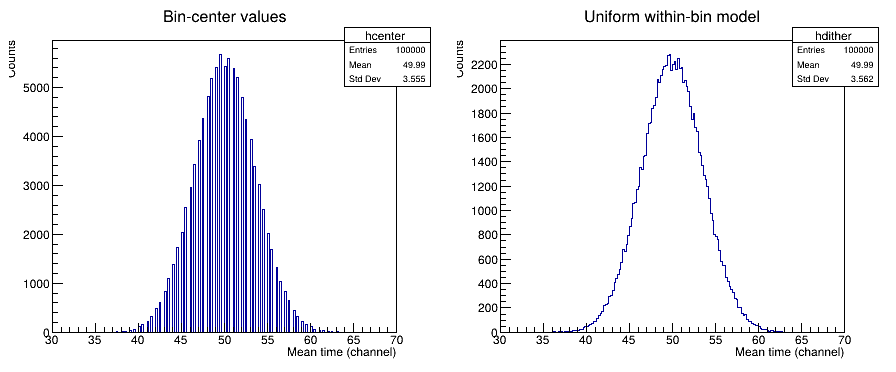

In [3]:
TRandom3 rng(1301);
TH1D *hcenter = new TH1D("hcenter","Bin-center values;Mean time (channel);Counts",200,30,70);
TH1D *hdither = new TH1D("hdither","Uniform within-bin model;Mean time (channel);Counts",200,30,70);
for (int i=0; i<100000; ++i) {
    int left = std::floor(rng.Gaus(50,5));
    int right = std::floor(rng.Gaus(50,5));
    hcenter->Fill(((left+0.5)+(right+0.5))/2);
    hdither->Fill(((left+rng.Uniform())+(right+rng.Uniform()))/2);
}
TCanvas *c1 = new TCanvas("c1","Quantization",900,400);
c1->Divide(2,1);
c1->cd(1); hcenter->Draw();
c1->cd(2); hdither->Draw();
c1->Draw();
cout << "Bin centers: mean=" << hcenter->GetMean() << ", RMS=" << hcenter->GetStdDev() << endl;
cout << "Dither model: mean=" << hdither->GetMean() << ", RMS=" << hdither->GetStdDev() << endl;

<h2>3. 用于后续分析</h2><p>保留原始码和状态，再生成刻度后的幅度、时间。有效性检查与阈值选择记录在分析中；是否使用 dithering 是量化模型的选择，不是所有数据的必做步骤。</p>